## Credit Card Approval Prediction

### About Dataset
A Credit Card Dataset for Machine Learning!

### Context
Credit score cards are a common risk control method in the financial industry. It uses personal information and data submitted by credit card applicants to predict the probability of future defaults and credit card borrowings. The bank is able to decide whether to issue a credit card to the applicant. Credit scores can objectively quantify the magnitude of risk.
 
Generally speaking, credit score cards are based on historical data. Once encountering large economic fluctuations. Past models may lose their original predictive power. Logistic model is a common method for credit scoring. Because Logistic is suitable for binary classification tasks and can calculate the coefficients of each feature. In order to facilitate understanding and operation, the score card will multiply the logistic regression coefficient by a certain value (such as 100) and round it.
 
At present, with the development of machine learning algorithms. More predictive methods such as Boosting, Random Forest, and Support Vector Machines have been introduced into credit card scoring. However, these methods often do not have good transparency. It may be difficult to provide customers and regulators with a reason for rejection or acceptance.

### Task
Build a machine learning model to predict if an applicant is 'good' or 'bad' client, different from other tasks, the definition of 'good' or 'bad' is not given. You should use some techique, such as vintage analysis to construct you label. Also, unbalance data problem is a big problem in this task.

---


## Previsão de aprovação de cartão de crédito

### Sobre o conjunto de dados
Um conjunto de dados de cartões de crédito para aprendizado de máquina!

### Contexto
Os sistemas de pontuação de crédito são um método comum de controle de risco no setor financeiro. Eles utilizam informações pessoais e dados fornecidos pelos solicitantes de cartões de crédito para prever a probabilidade de inadimplência e empréstimos futuros. O banco pode, assim, decidir se concede ou não um cartão de crédito ao solicitante. As pontuações de crédito podem quantificar objetivamente a magnitude do risco. De modo geral, os sistemas de pontuação de crédito são baseados em dados históricos. Diante de grandes flutuações econômicas, os modelos antigos podem perder seu poder preditivo original. O modelo logístico é um método comum para pontuação de crédito, pois é adequado para tarefas de classificação binária e pode calcular os coeficientes de cada característica. Para facilitar a compreensão e a operação, o sistema de pontuação multiplica o coeficiente de regressão logística por um determinado valor (como 100) e o arredonda. Atualmente, com o desenvolvimento de algoritmos de aprendizado de máquina, mais métodos preditivos, como Boosting, Random Forest e Support Vector Machines, foram introduzidos na pontuação de crédito. No entanto, esses métodos geralmente não possuem boa transparência. Pode ser difícil fornecer aos clientes e aos órgãos reguladores uma justificativa para a aprovação ou rejeição de um pedido.

### Tarefa
Construa um modelo de aprendizado de máquina para prever se um candidato é um cliente "bom" ou "ruim". Diferentemente de outras tarefas, a definição de "bom" ou "ruim" não é fornecida. Você deve usar alguma técnica, como análise de dados antigos , para construir seus rótulos. Além disso, o problema de dados desbalanceados é um grande desafio nesta tarefa.

##### Imports

---

##### Importações

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

##### Load Dataset > Credit Record

---

##### Carregamento do Conjunto de Dados > Registro de Crédito

In [3]:
df_credit = pd.read_csv('credit_record.csv')

In [4]:
display(df_credit.head(11))

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C
5,5001712,-1,C
6,5001712,-2,C
7,5001712,-3,C
8,5001712,-4,C
9,5001712,-5,C


In [5]:
df_credit.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype
---  ------          --------------    -----
 0   ID              1048575 non-null  int64
 1   MONTHS_BALANCE  1048575 non-null  int64
 2   STATUS          1048575 non-null  str  
dtypes: int64(2), str(1)
memory usage: 24.0 MB


In [6]:
df_credit.isnull().sum()

ID                0
MONTHS_BALANCE    0
STATUS            0
dtype: int64

In [7]:
df_credit['STATUS'].value_counts()

STATUS
C    442031
0    383120
X    209230
1     11090
5      1693
2       868
3       320
4       223
Name: count, dtype: int64

##### Definition of good and bad clients

---

##### Definição de clientes bons e ruins

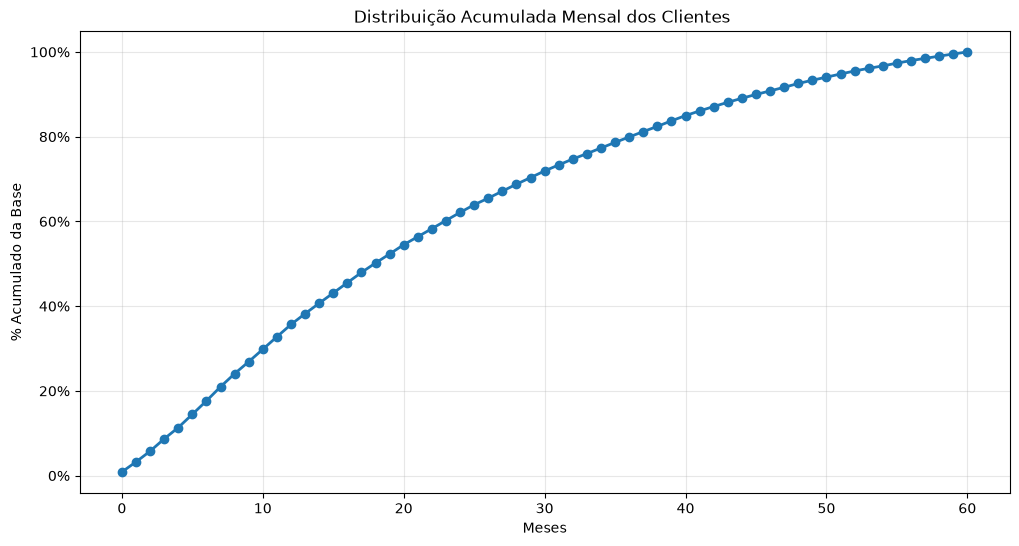

In [8]:
# Criei um DataFrame agrupando os dados por ID, calculando o mês de abertura (open_month) e o mês final (end_month) para cada ID.
# Em seguida, ordenei o DataFrame pelo ID em ordem crescente e redefini o índice.

df_grouped = pd.DataFrame()
df_grouped = (
    df_credit.groupby('ID', as_index=False)['MONTHS_BALANCE']
    .agg(open_month='min', end_month='max')
    .sort_values('ID')
    .reset_index(drop=True)
)

# Calculei a janela de observação (window) subtraindo o mês de abertura do mês final para cada ID.

df_grouped['window'] = df_grouped['end_month'] - df_grouped['open_month']

# Criei um gráfico de linha para visualizar a distribuição acumulada das janelas de observação.

distribution = (
    df_grouped['window']
    .value_counts(normalize=True)
    .sort_index()
)

cumulative = distribution.cumsum() * 100

plt.figure(figsize=(12, 6))
plt.plot(
    cumulative.index,
    cumulative.values,
    marker='o',
    linewidth=2
)

plt.xlabel('Meses')
plt.ylabel('% Acumulado da Base')
plt.title('Distribuição Acumulada Mensal dos Clientes ')
plt.gca().yaxis.set_major_formatter(
    mtick.PercentFormatter()
)

plt.grid(alpha=0.3)
plt.show()


In [9]:
# Criei uma tabela para analisar a distribuição acumulada, de 1 até 60 meses, aumentando de 1 em 1, o intuito é analisar as janelas de observação.

import pandas as pd

intervals = list(range(1, 61))

result = pd.DataFrame({
    'window': intervals,
    'percentual_acumulado': [
        round((df_grouped['window'] <= x).mean() * 100, 2)
        for x in intervals
    ]
})

result

,window,percentual_acumulado
0,1,3.23
1,2,5.76
2,3,8.67
3,4,11.34
4,5,14.47
5,6,17.64
6,7,20.97
7,8,24.06
8,9,26.89
9,10,29.82


Based on the observed window, I chose to consider a minimum account tenure of 36 months within the system, retaining 21% of the base for the sample.

-----------------------------------------------------------------------------------------------------------------------------------------------------------

Com base na janela observada, optei por considerar o mínimo de 36 meses da existência da conta no sistema, ficando com 21% da base para a amostragem.

##### Analysis and Processing of the DataFrame on Good and Bad Customers

---

##### Análise e Tratamento do Relatório de clientes bons e ruins 

In [10]:
coverage = pd.DataFrame({
    'window_minima': [36],
    'clientes_elegiveis': [
        (df_grouped['window'] >= 36).sum()
    ],
    'clientes_total': [
        df_grouped['ID'].nunique()
    ]
})

coverage['percentual_base'] = round(
    coverage['clientes_elegiveis']
    / coverage['clientes_total']
    * 100
, 2)

coverage

,window_minima,clientes_elegiveis,clientes_total,percentual_base
0,36,9820,45985,21.35


In [11]:
# Filtrei o DataFrame df_grouped para incluir apenas os registros com janelas de observação (window) maiores ou iguais a 36 meses, criando o DataFrame da amostra.

eligible_ids = df_grouped.loc[
    df_grouped['window'] >= 36,
    'ID'
]

df_credit_eligible = df_credit[
    df_credit['ID'].isin(eligible_ids)
].copy()

df_credit_eligible['bad_event'] = (
    df_credit_eligible['STATUS'].isin(['2', '3', '4', '5'])
    .astype('int8')
)

df_target = (
    df_credit_eligible
    .groupby('ID')['bad_event']
    .max()
    .reset_index(name='TARGET')
)

df_target['TARGET_LABEL'] = df_target['TARGET'].map({
    0: 'good',
    1: 'bad'
})

target_distribution = (
    df_target['TARGET_LABEL']
    .value_counts()
    .rename_axis('TARGET')
    .reset_index(name='clientes')
)

target_distribution['percentual'] = round(
    target_distribution['clientes']
    / target_distribution['clientes'].sum()
    * 100
, 2)

target_distribution

,TARGET,clientes,percentual
0,good,9485,96.59
1,bad,335,3.41


Considering customers with accounts activated within a window equal to or greater than 36 months, it was observed that 3.41% of bad customers prevailed within this interval. Therefore, it is important to have a longer exposure window for customers who may present an event indicating default risk.

---

Considerando os clientes com as contas ativadas na janela igual ou superior a 36 meses, foi observado que 3,41% dos clientes ruins prevaleceram dentro desse intervalo. Dessa forma, é importante ter um intervalo maior de exposição dos clientes que possivelmente vão apresentar algum evento que possa indicar o risco de inadimplência.

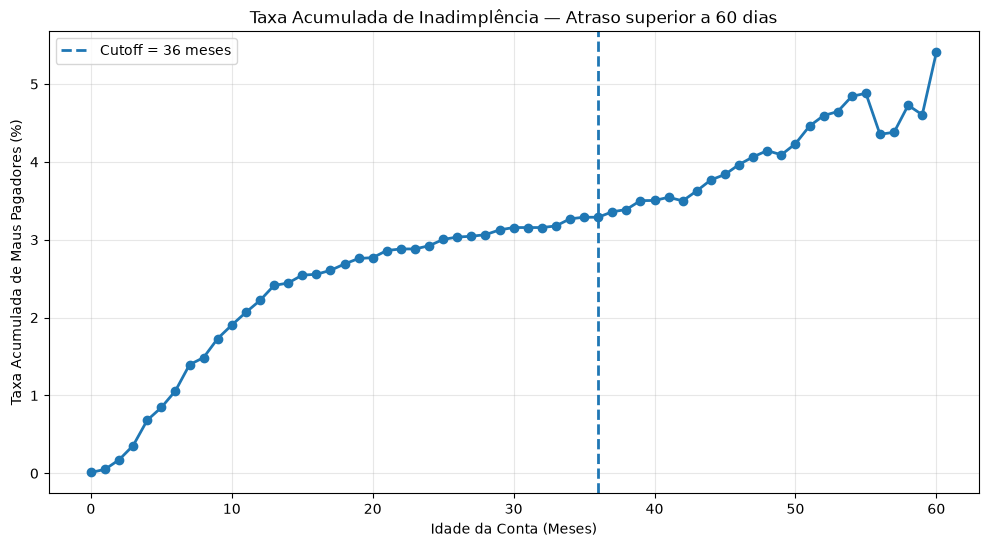

In [12]:
df_credit_eligible = df_credit.merge(
    df_grouped[['ID', 'open_month', 'window']],
    on='ID',
    how='inner'
)

df_credit_eligible = df_credit_eligible[
    df_credit_eligible['window'] >= 36
].copy()

df_credit_eligible['bad_event'] = (
    df_credit_eligible['STATUS'].isin(['2', '3', '4', '5'])
    .astype('int8')
)

df_credit_eligible['month_on_book'] = (
    df_credit_eligible['MONTHS_BALANCE']
    - df_credit_eligible['open_month']
)

df_credit_eligible = df_credit_eligible.sort_values(
    ['ID', 'month_on_book']
).copy()

df_credit_eligible['cum_bad'] = (
    df_credit_eligible
    .groupby('ID')['bad_event']
    .cummax()
)

vintage_overall = (
    df_credit_eligible
    .groupby('month_on_book', as_index=False)
    .agg(
        cum_bad_rate=('cum_bad', 'mean'),
        clients=('ID', 'nunique')
    )
)

vintage_overall['cum_bad_rate'] *= 100

plt.figure(figsize=(12, 6))

plt.plot(
    vintage_overall['month_on_book'],
    vintage_overall['cum_bad_rate'],
    marker='o',
    linewidth=2
)

plt.axvline(
    x=36,
    linestyle='--',
    linewidth=2,
    label='Cutoff = 36 meses'
)

plt.xlabel('Idade da Conta (Meses)')
plt.ylabel('Taxa Acumulada de Maus Pagadores (%)')
plt.title('Taxa Acumulada de Inadimplência — Atraso superior a 60 dias')

plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [13]:
rate_36 = vintage_overall.loc[
    vintage_overall['month_on_book'] == 36,
    'cum_bad_rate'
].iloc[0]

rate_final = vintage_overall['cum_bad_rate'].max()

coverage_bad = rate_36 / rate_final * 100

print(f'Taxa de inadimplência acumulada no Mês 36: {rate_36:.2f}%')
print(f'Taxa de inadimplência acumulada final: {rate_final:.2f}%')
print(f'Eventos capturados até 36 meses: {coverage_bad:.2f}%')

Taxa de inadimplência acumulada no Mês 36: 3.29%
Taxa de inadimplência acumulada final: 5.41%
Eventos capturados até 36 meses: 60.85%


Based on the analysis performed, it was determined that ~60% of default events were captured within an observation window greater than 36 months of account activation, with delays exceeding 60 days. Regarding the observation window for accounts above 36 months, I emphasize that ~40% of future default events were not considered; this limitation was chosen to preserve at least 21% of the observed customer base.

---

Conforme a análise realizada, foi possível identificar que ~60% dos eventos de inadimplência foram capturados na janela de observação superior a 36 meses de ativação da conta, com atrasos superiores a 60 dias. Em relação a janela de observação das contas acima de 36 meses, ressalto que ~40% dos eventos de inadimplência que vão acontecer não foram considerados, essa limitação foi escolhida para preservar ao menos 21% da base de clientes observados.  


##### Load Dataset > Application Record

---

##### Carregamento do Conjunto de Dados > Registro de Candidatura

In [14]:
df_record = pd.read_csv('application_record.csv')

In [15]:
df_record.head(11)

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
5,5008810,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
6,5008811,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
7,5008812,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,1,0,0,0,NaN,1.0
8,5008813,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,1,0,0,0,NaN,1.0
9,5008814,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,1,0,0,0,NaN,1.0


In [16]:
df_record.info()

<class 'pandas.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  str    
 2   FLAG_OWN_CAR         438557 non-null  str    
 3   FLAG_OWN_REALTY      438557 non-null  str    
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  str    
 7   NAME_EDUCATION_TYPE  438557 non-null  str    
 8   NAME_FAMILY_STATUS   438557 non-null  str    
 9   NAME_HOUSING_TYPE    438557 non-null  str    
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL           438557 

In [17]:
df_record.isnull().sum()

ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134203
CNT_FAM_MEMBERS             0
dtype: int64

In [18]:
df_occupation = df_record[df_record['OCCUPATION_TYPE'].isna()].copy()

df_occupation

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
7,5008812,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,1,0,0,0,NaN,1.0
8,5008813,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,1,0,0,0,NaN,1.0
9,5008814,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,1,0,0,0,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438549,6840098,F,N,Y,0,135000.0,Pensioner,Secondary / secondary special,Separated,House / apartment,-22717,365243,1,0,0,0,NaN,1.0
438550,6840100,F,N,Y,0,135000.0,Pensioner,Secondary / secondary special,Separated,House / apartment,-22717,365243,1,0,0,0,NaN,1.0
438551,6840102,F,N,Y,0,135000.0,Pensioner,Secondary / secondary special,Separated,House / apartment,-22717,365243,1,0,0,0,NaN,1.0
438552,6840104,M,N,Y,0,135000.0,Pensioner,Secondary / secondary special,Separated,House / apartment,-22717,365243,1,0,0,0,NaN,1.0


In [19]:
df_record.duplicated(subset=['ID']).sum()

np.int64(47)

In [20]:
duplicates = df_record[df_record.duplicated(subset=['ID'], keep=False)].sort_values(by='ID')

duplicates

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
425023,7022197,F,N,Y,0,450000.0,Commercial associate,Higher education,Separated,House / apartment,-19813,-1799,1,0,0,1,NaN,1.0
426818,7022197,M,Y,Y,3,135000.0,Working,Secondary / secondary special,Married,House / apartment,-11945,-735,1,0,0,1,Laborers,5.0
431911,7022327,M,Y,Y,0,256500.0,Commercial associate,Higher education,Married,House / apartment,-21503,-1674,1,0,0,1,Core staff,2.0
431545,7022327,F,N,Y,0,135000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-14771,-5298,1,0,0,0,High skill tech staff,1.0
425486,7023108,M,Y,Y,1,67500.0,Working,Secondary / secondary special,Married,House / apartment,-15156,-1696,1,1,0,0,Core staff,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426563,7836711,F,N,Y,2,292500.0,Working,Higher education,Married,House / apartment,-13747,-4386,1,0,1,0,Accountants,4.0
428620,7836971,F,N,Y,0,103500.0,Working,Secondary / secondary special,Civil marriage,House / apartment,-13383,-2798,1,0,1,0,Sales staff,2.0
421464,7836971,M,Y,N,1,157500.0,Working,Secondary / secondary special,Married,House / apartment,-13771,-5520,1,0,0,0,NaN,3.0
422068,7838075,M,N,Y,0,337500.0,Commercial associate,Secondary / secondary special,Married,House / apartment,-18198,-1275,1,0,0,1,Drivers,2.0


In the application records report, 47 duplicate IDs were identified; however, these IDs presented different registration data. Apparently, data from different customers was entered using the same ID. Therefore, for duplicate IDs, we will keep only the first record made in the database.

---

No relatório de registros de candidatura, foi identificado 47 IDs duplicados, mas os IDs estavam apresentando dados diferentes no cadastro, aparentemente foi inserido dados de clientes diferentes com o mesmo ID, dessa maneira, para os IDs duplicados, vamos permanecer com o primeiro registro realizado no banco de dados.

In [21]:
df_record.drop_duplicates(subset=['ID'], keep='first', inplace=True)
df_record.duplicated(subset=['ID']).sum()

np.int64(0)

In [22]:
df_record.info()

<class 'pandas.DataFrame'>
Index: 438510 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438510 non-null  int64  
 1   CODE_GENDER          438510 non-null  str    
 2   FLAG_OWN_CAR         438510 non-null  str    
 3   FLAG_OWN_REALTY      438510 non-null  str    
 4   CNT_CHILDREN         438510 non-null  int64  
 5   AMT_INCOME_TOTAL     438510 non-null  float64
 6   NAME_INCOME_TYPE     438510 non-null  str    
 7   NAME_EDUCATION_TYPE  438510 non-null  str    
 8   NAME_FAMILY_STATUS   438510 non-null  str    
 9   NAME_HOUSING_TYPE    438510 non-null  str    
 10  DAYS_BIRTH           438510 non-null  int64  
 11  DAYS_EMPLOYED        438510 non-null  int64  
 12  FLAG_MOBIL           438510 non-null  int64  
 13  FLAG_WORK_PHONE      438510 non-null  int64  
 14  FLAG_PHONE           438510 non-null  int64  
 15  FLAG_EMAIL           438510 non-n

In [23]:
df_occupation = df_record[df_record['OCCUPATION_TYPE'].isna()].copy()

df_occupation

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
7,5008812,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,1,0,0,0,NaN,1.0
8,5008813,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,1,0,0,0,NaN,1.0
9,5008814,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,1,0,0,0,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438549,6840098,F,N,Y,0,135000.0,Pensioner,Secondary / secondary special,Separated,House / apartment,-22717,365243,1,0,0,0,NaN,1.0
438550,6840100,F,N,Y,0,135000.0,Pensioner,Secondary / secondary special,Separated,House / apartment,-22717,365243,1,0,0,0,NaN,1.0
438551,6840102,F,N,Y,0,135000.0,Pensioner,Secondary / secondary special,Separated,House / apartment,-22717,365243,1,0,0,0,NaN,1.0
438552,6840104,M,N,Y,0,135000.0,Pensioner,Secondary / secondary special,Separated,House / apartment,-22717,365243,1,0,0,0,NaN,1.0


In [24]:
tab = df_record.groupby('NAME_INCOME_TYPE').agg(
    Total=('OCCUPATION_TYPE', 'size'),
    Nulos=('OCCUPATION_TYPE', lambda x: x.isna().sum())
).reset_index()

tab['% Nulos na categoria'] = (
    (tab['Nulos'] / tab['Total']) * 100
).round(2).astype(str) + '%'

tab = tab.sort_values(by='Nulos', ascending=False)

tab

,NAME_INCOME_TYPE,Total,Nulos,% Nulos na categoria
1,Pensioner,75488,75352,99.82%
4,Working,226076,35884,15.87%
0,Commercial associate,100744,16742,16.62%
2,State servant,36185,6210,17.16%
3,Student,17,5,29.41%


In [25]:
df_record['NAME_INCOME_TYPE'] = (
    df_record['NAME_INCOME_TYPE']
    .astype('string')
    .str.strip()
)

df_record['OCCUPATION_TYPE'] = (
    df_record['OCCUPATION_TYPE']
    .astype('string')
    .str.strip()
)

df_record['elective_group'] = np.select(
    [
        (df_record['NAME_INCOME_TYPE'].ne('Pensioner')) &
        (df_record['OCCUPATION_TYPE'].isna()),

        (df_record['NAME_INCOME_TYPE'].ne('Pensioner')) &
        (df_record['OCCUPATION_TYPE'].notna()),

        (df_record['NAME_INCOME_TYPE'].eq('Pensioner'))
    ],
    [0, 1, 2],
    default=np.nan
).astype('int64')

In [26]:
tab = df_record.groupby('elective_group').size().reset_index(name='count').sort_values(by='count', ascending=False)
tab['%'] = (tab['count'] / tab['count'].sum() * 100).round(2).astype(str) + '%'

tab

,elective_group,count,%
1,1,304181,69.37%
2,2,75488,17.21%
0,0,58841,13.42%


Analyzing the report, 30% of clients did not state their occupation. Among registered clients, some are retirees who naturally do not have an occupation; however, for other income types, this information is missing for several clients—such as employees, public servants, commercial partners, and students. Therefore, to make it possible to separate these client groups in future analyses, I created elective groups based on the following criteria:

Group 0 = Clients who are NOT retirees AND do NOT have an occupation (69%)
Group 1 = Clients who are NOT retirees AND HAVE an occupation (17%)
Group 2 = Clients who ARE retirees (13%)

The objective is to analyze in the future whether there is a significant difference between these groups before training the model.

---

Analisando o relatório, 30% dos clientes não informaram a sua ocupação, dentre os clientes cadastrados, parte deles são pensionistas que naturalmente não possuem ocupação, mas para os outros tipos de renda, temos clientes que essa informação está nula, como trabalhadores, servidores públicos, associados comerciais e estudantes. Dessa forma, para que nas próximas analises seja possível separar esses grupos de clientes, criei grupos eletivos, seguindo os critérios abaixo:

Grupo 0 = Clientes que não são pensionistas E não possuem ocupação (69%)
Grupo 1 = Clientes que não são pensionistas E possuem ocupação (17%)
Grupo 2 = Clientes que são pensionistas (13%)

In [27]:
df_student = df_record[
    (df_record['NAME_INCOME_TYPE'] == 'Student')
    & (df_record['OCCUPATION_TYPE'].notna())
]

df_student

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,elective_group
1464,5010456,F,N,Y,0,171000.0,Student,Higher education,Married,House / apartment,-18756,-3904,1,0,0,1,Core staff,2.0,1
1465,5010457,F,N,Y,0,171000.0,Student,Higher education,Married,House / apartment,-18756,-3904,1,0,0,1,Core staff,2.0,1
1466,5010458,F,N,Y,0,171000.0,Student,Higher education,Married,House / apartment,-18756,-3904,1,0,0,1,Core staff,2.0,1
1467,5010459,F,N,Y,0,171000.0,Student,Higher education,Married,House / apartment,-18756,-3904,1,0,0,1,Core staff,2.0,1
1468,5010460,F,N,Y,0,171000.0,Student,Higher education,Married,House / apartment,-18756,-3904,1,0,0,1,Core staff,2.0,1
1469,5010461,F,N,Y,0,171000.0,Student,Higher education,Married,House / apartment,-18756,-3904,1,0,0,1,Core staff,2.0,1
1470,5010462,F,N,Y,0,171000.0,Student,Higher education,Married,House / apartment,-18756,-3904,1,0,0,1,Core staff,2.0,1
1471,5010463,F,N,Y,0,171000.0,Student,Higher education,Married,House / apartment,-18756,-3904,1,0,0,1,Core staff,2.0,1
16563,5047796,F,N,Y,1,112500.0,Student,Secondary / secondary special,Civil marriage,House / apartment,-12127,-795,1,0,0,0,Laborers,3.0,1
16564,5047798,F,N,Y,1,112500.0,Student,Secondary / secondary special,Civil marriage,House / apartment,-12127,-795,1,0,0,0,Laborers,3.0,1


In [28]:
df_student['AGE_YEARS'] = (df_student['DAYS_BIRTH'].abs() / 365).round(2)
df_student['EMPLOYED_YEARS'] = (df_student['DAYS_EMPLOYED'].abs() / 365).round(2)

df_student['AGE_TEXT'] = df_student['DAYS_BIRTH'].abs().apply(
    lambda d: f"{int(d // 365)} anos e {int((d % 365) // 30)} meses"
)

df_student['EMPLOYED_TEXT'] = df_student['DAYS_EMPLOYED'].abs().apply(
    lambda d: f"{int(d // 365)} anos e {int((d % 365) // 30)} meses"
)

df_student[['DAYS_BIRTH', 'AGE_YEARS', 'AGE_TEXT', 'DAYS_EMPLOYED', 'EMPLOYED_YEARS', 'EMPLOYED_TEXT']]

,DAYS_BIRTH,AGE_YEARS,AGE_TEXT,DAYS_EMPLOYED,EMPLOYED_YEARS,EMPLOYED_TEXT
1464,-18756,51.39,51 anos e 4 meses,-3904,10.70,10 anos e 8 meses
1465,-18756,51.39,51 anos e 4 meses,-3904,10.70,10 anos e 8 meses
1466,-18756,51.39,51 anos e 4 meses,-3904,10.70,10 anos e 8 meses
1467,-18756,51.39,51 anos e 4 meses,-3904,10.70,10 anos e 8 meses
1468,-18756,51.39,51 anos e 4 meses,-3904,10.70,10 anos e 8 meses
1469,-18756,51.39,51 anos e 4 meses,-3904,10.70,10 anos e 8 meses
1470,-18756,51.39,51 anos e 4 meses,-3904,10.70,10 anos e 8 meses
1471,-18756,51.39,51 anos e 4 meses,-3904,10.70,10 anos e 8 meses
16563,-12127,33.22,33 anos e 2 meses,-795,2.18,2 anos e 2 meses
16564,-12127,33.22,33 anos e 2 meses,-795,2.18,2 anos e 2 meses


Analyzing the "Students" income group, there are registered clients between 33 and 52 years old in the report, as well as 2 to 10 years in their current job position. This shows that there are irregular records in this category, but since it represents a minimal portion of the database, they will remain for the next stage.

---

Analisando o grupo de renda "Estudantes", existem clientes cadastrados com 33 até 52 anos no relatório, como também de 2 até 10 anos no cargo de trabalho atual, isso nos mostra que nessa categoria existem cadastros irregulares, mas como seria uma parcela mínima da base, eles vão permanecer para a próxima etapa.
 

Considering that the report processing has been completed, I will create the analysis DataFrame by merging the df_record DataFrame with df_target, which from now on will be our sample to be analyzed. The main objective is to extract insights from the data.

---

Considerando que os tratamentos dos relatórios foi realizado, irei criar o DataFrame de análise, mesclando o DataFrame df_record com o df_target, que daqui em diante será a nossa amostragem a ser analisada. O objetivo principal é obter insights dos dados.

In [29]:
df_analysis = df_record.merge(
    df_target[['ID', 'TARGET']],
    on='ID',
    how='inner'
)

df_analysis

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,elective_group,TARGET
0,5008811,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,1,0
1,5112956,M,Y,Y,0,270000.0,Working,Higher education,Married,House / apartment,-16872,-769,1,1,1,1,Accountants,2.0,1,0
2,5008834,F,N,Y,1,112500.0,Working,Secondary / secondary special,Single / not married,House / apartment,-10968,-1620,1,0,0,0,<NA>,2.0,0,0
3,5008840,M,N,Y,1,405000.0,Commercial associate,Higher education,Married,House / apartment,-11842,-2016,1,0,0,0,Managers,3.0,1,0
4,5008874,F,N,Y,2,126000.0,Commercial associate,Higher education,Married,House / apartment,-12411,-1773,1,0,0,1,Managers,4.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6646,5142964,M,N,N,1,180000.0,Working,Secondary / secondary special,Married,House / apartment,-10656,-926,1,1,1,0,Laborers,3.0,1,1
6647,5143582,M,Y,N,0,157500.0,Working,Incomplete higher,Married,With parents,-9124,-960,1,1,0,0,Drivers,2.0,1,1
6648,5145817,F,N,Y,0,90000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-22011,365243,1,0,0,0,<NA>,2.0,2,1
6649,5146078,F,N,Y,1,108000.0,Working,Secondary / secondary special,Single / not married,House / apartment,-12723,-1132,1,1,1,0,Sales staff,1.0,1,1


In [30]:
table = pd.DataFrame({
    'Quantidade': df_analysis['TARGET'].value_counts().sort_index(),
    'Percentual (%)': (
        df_analysis['TARGET']
        .value_counts(normalize=True)
        .sort_index()
        * 100
    ).round(2)
})

table

,Quantidade,Percentual (%)
TARGET,,
0,6357,95.58
1,294,4.42


Note: After performing the merge, the proportion of good and bad clients changed. We will be working with 95.58% good clients, while bad clients increased to 4.42% of the sample for training the model later on.

---

Observação: Após a realização da mesclagem, a proporção de clientes bons e ruins se alterou, iremos trabalhar com 95,58% dos clientes bons, enquanto que os clientes ruins aumentou para a 4,42% da amostragem para treinamento do modelo posteriormente.

##### Column Processing

---

##### Tratamentos das Colunas

In [31]:
# Realizei o cálculo da idade em anos e do tempo de emprego em anos, utilizando os campos 'DAYS_BIRTH' e 'DAYS_EMPLOYED', respectivamente. Em seguida, arredondei os valores para duas casas decimais.
df_analysis['AGE_YEARS'] = (df_analysis['DAYS_BIRTH'].abs() / 365).round(2)
df_analysis['EMPLOYED_YEARS'] = (df_analysis['DAYS_EMPLOYED'].abs() / 365).round(2)

# Convertendo a coluna CNT_FAM_MEMBERS de float para int, pois o número de membros da família deve ser um valor inteiro.
df_analysis['CNT_FAM_MEMBERS'] = df_analysis['CNT_FAM_MEMBERS'].astype('Int64')

##### Exploratory Data Analysis (EDA)

---

##### Análise Exploratória dos Dados (EDA)

In [32]:
# Configurando o pandas para exibir números de ponto flutuante com duas casas decimais e separador de milhar, melhorando a legibilidade dos dados.

pd.set_option(
    'display.float_format',
    lambda x: f'{x:,.2f}'
)

In [33]:
df_analysis.drop(columns='ID').describe()

,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,elective_group,TARGET,AGE_YEARS,EMPLOYED_YEARS
count,"6,651.00","6,651.00","6,651.00","6,651.00","6,651.00","6,651.00","6,651.00","6,651.00","6,651.00","6,651.00","6,651.00","6,651.00","6,651.00"
mean,0.42,"187,000.50","-16,395.08","59,771.11",1.00,0.24,0.31,0.09,2.21,1.03,0.04,44.92,177.17
std,0.76,"98,110.11","3,994.21","138,448.08",0.00,0.43,0.46,0.29,0.91,0.56,0.21,10.94,373.23
min,0.00,"30,150.00","-25,152.00","-15,661.00",1.00,0.00,0.00,0.00,1.00,0.00,0.00,22.87,0.18
25%,0.00,"124,875.00","-19,605.00","-3,503.00",1.00,0.00,0.00,0.00,2.00,1.00,0.00,36.02,3.81
50%,0.00,"162,000.00","-16,053.00","-1,830.00",1.00,0.00,0.00,0.00,2.00,1.00,0.00,43.98,7.95
75%,1.00,"225,000.00","-13,145.00",-424.50,1.00,0.00,1.00,0.00,3.00,1.00,0.00,53.71,17.69
max,14.00,"1,575,000.00","-8,347.00","365,243.00",1.00,1.00,1.00,1.00,15.00,2.00,1.00,68.91,"1,000.67"


In [34]:
df_analysis['EMPLOYED_SPECIAL'] = (
    df_analysis['DAYS_EMPLOYED'] == 365243
)

df_analysis['EMPLOYED_SPECIAL'].value_counts()

EMPLOYED_SPECIAL
False    5518
True     1133
Name: count, dtype: int64

In [35]:
df_analysis.loc[
    df_analysis['EMPLOYED_SPECIAL'],
    [
        'NAME_INCOME_TYPE',
        'OCCUPATION_TYPE',
        'DAYS_EMPLOYED'
    ]
].drop_duplicates()

,NAME_INCOME_TYPE,OCCUPATION_TYPE,DAYS_EMPLOYED
8,Pensioner,<NA>,365243


##### Handling Outliers in DAYS_EMPLOYED

During exploratory analysis, an outlier was identified in the DAYS_EMPLOYED variable: 365,243 days, which corresponds to approximately 1,000.67 years after conversion to years.

This value is not consistent with actual employment length and can therefore distort statistical measures such as mean and standard deviation, as well as affect distribution analyses.

Therefore, the original value will be preserved, and an indicator variable (EMPLOYED_SPECIAL) will be created to identify these records. For numerical analyses, a treated version of the variable will be used, in which this special value will be considered missing (NaN).

---

##### Tratamento de valores discrepantes em DAYS_EMPLOYED

Durante a análise exploratória, foi identificado um valor discrepante na variável DAYS_EMPLOYED: 365243 dias, que corresponde aproximadamente a 1000,67 anos após a conversão para anos.

Esse valor não é compatível com um tempo de emprego real e, portanto, pode distorcer medidas estatísticas como média e desvio-padrão, além de afetar análises de distribuição.

Dessa forma, o valor original será preservado e será criada uma variável indicadora (EMPLOYED_SPECIAL) para identificar esses registros. Para as análises numéricas, será utilizada uma versão tratada da variável, na qual esse valor especial será considerado ausente (NaN).

In [36]:
df_analysis['EMPLOYED_YEARS'] = (
    df_analysis['DAYS_EMPLOYED'].abs() / 365
).round(2)

df_analysis.loc[
    df_analysis['EMPLOYED_SPECIAL'],
    'EMPLOYED_YEARS'
] = np.nan

In [37]:
print(
    f"Registros com valor especial: "
    f"{df_analysis['EMPLOYED_SPECIAL'].sum():,}"
)

print(
    f"Percentual da base: "
    f"{df_analysis['EMPLOYED_SPECIAL'].mean() * 100:.2f}%"
)

Registros com valor especial: 1,133
Percentual da base: 17.04%


In [38]:
df_analysis.drop(columns='ID').describe()

,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,elective_group,TARGET,AGE_YEARS,EMPLOYED_YEARS
count,"6,651.00","6,651.00","6,651.00","6,651.00","6,651.00","6,651.00","6,651.00","6,651.00","6,651.00","6,651.00","6,651.00","6,651.00","5,518.00"
mean,0.42,"187,000.50","-16,395.08","59,771.11",1.00,0.24,0.31,0.09,2.21,1.03,0.04,44.92,8.08
std,0.76,"98,110.11","3,994.21","138,448.08",0.00,0.43,0.46,0.29,0.91,0.56,0.21,10.94,6.86
min,0.00,"30,150.00","-25,152.00","-15,661.00",1.00,0.00,0.00,0.00,1.00,0.00,0.00,22.87,0.18
25%,0.00,"124,875.00","-19,605.00","-3,503.00",1.00,0.00,0.00,0.00,2.00,1.00,0.00,36.02,3.18
50%,0.00,"162,000.00","-16,053.00","-1,830.00",1.00,0.00,0.00,0.00,2.00,1.00,0.00,43.98,6.50
75%,1.00,"225,000.00","-13,145.00",-424.50,1.00,0.00,1.00,0.00,3.00,1.00,0.00,53.71,10.69
max,14.00,"1,575,000.00","-8,347.00","365,243.00",1.00,1.00,1.00,1.00,15.00,2.00,1.00,68.91,42.91


In [39]:
categorical_variables = [
    'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE',
    'OCCUPATION_TYPE',
]

# Taxa geral de Bad da carteira
taxa_media_geral = df_analysis['TARGET'].mean()

print(
    f"Taxa média geral de Bad: "
    f"{taxa_media_geral * 100:.2f}%"
)

percentage_tables = {}

for var in categorical_variables:

    summary = (
        df_analysis
        .groupby(var, dropna=False)
        .agg(
            Total_Clientes=('TARGET', 'count'),
            Qtde_Bad=('TARGET', 'sum')
        )
        .reset_index()
    )

    summary['%_Bad'] = (
        summary['Qtde_Bad']
        / summary['Total_Clientes']
        * 100
    )

    summary['Índice_vs_Carteira'] = (
        (summary['%_Bad'] / 100)
        / taxa_media_geral
    )

    summary['Dif_vs_Media'] = (
        (summary['Índice_vs_Carteira'] - 1) * 100
    )

    summary['+_100'] = (
        summary['Total_Clientes'] >= 100
    )

    summary['%_Bad'] = summary['%_Bad'].round(2)
    summary['Índice_vs_Carteira'] = summary['Índice_vs_Carteira'].round(2)
    summary['Dif_vs_Media'] = summary['Dif_vs_Media'].round(2)

    summary = summary.sort_values(
        by='%_Bad',
        ascending=False
    )

    percentage_tables[var] = summary

    print(f"\n--- Taxa de Bad para: {var} ---")
    display(summary)



Taxa média geral de Bad: 4.42%

--- Taxa de Bad para: NAME_INCOME_TYPE ---


,NAME_INCOME_TYPE,Total_Clientes,Qtde_Bad,%_Bad,Índice_vs_Carteira,Dif_vs_Media,+_100
1,Pensioner,1137,60,5.28,1.19,19.38,True
0,Commercial associate,1543,69,4.47,1.01,1.16,True
4,Working,3422,145,4.24,0.96,-4.14,True
2,State servant,545,20,3.67,0.83,-16.98,True
3,Student,4,0,0.00,0.00,-100.00,False



--- Taxa de Bad para: NAME_EDUCATION_TYPE ---


,NAME_EDUCATION_TYPE,Total_Clientes,Qtde_Bad,%_Bad,Índice_vs_Carteira,Dif_vs_Media,+_100
3,Lower secondary,79,7,8.86,2.00,100.45,False
2,Incomplete higher,261,22,8.43,1.91,90.69,True
1,Higher education,1815,92,5.07,1.15,14.67,True
4,Secondary / secondary special,4488,173,3.85,0.87,-12.80,True
0,Academic degree,8,0,0.00,0.00,-100.00,False



--- Taxa de Bad para: NAME_FAMILY_STATUS ---


,NAME_FAMILY_STATUS,Total_Clientes,Qtde_Bad,%_Bad,Índice_vs_Carteira,Dif_vs_Media,+_100
4,Widow,274,21,7.66,1.73,73.38,True
3,Single / not married,741,43,5.80,1.31,31.28,True
2,Separated,378,19,5.03,1.14,13.71,True
1,Married,4739,191,4.03,0.91,-8.82,True
0,Civil marriage,519,20,3.85,0.87,-12.82,True



--- Taxa de Bad para: NAME_HOUSING_TYPE ---


,NAME_HOUSING_TYPE,Total_Clientes,Qtde_Bad,%_Bad,Índice_vs_Carteira,Dif_vs_Media,+_100
3,Office apartment,51,5,9.80,2.22,121.79,False
2,Municipal apartment,211,15,7.11,1.61,60.82,True
0,Co-op apartment,32,2,6.25,1.41,41.39,False
5,With parents,273,13,4.76,1.08,7.73,True
1,House / apartment,6007,256,4.26,0.96,-3.59,True
4,Rented apartment,77,3,3.90,0.88,-11.86,False



--- Taxa de Bad para: OCCUPATION_TYPE ---


,OCCUPATION_TYPE,Total_Clientes,Qtde_Bad,%_Bad,Índice_vs_Carteira,Dif_vs_Media,+_100
5,HR staff,13,1,7.69,1.74,74.02,False
6,High skill tech staff,273,17,6.23,1.41,40.87,True
3,Core staff,636,39,6.13,1.39,38.72,True
9,Low-skill Laborers,35,2,5.71,1.29,29.27,False
16,Security staff,110,6,5.45,1.23,23.40,True
4,Drivers,429,21,4.90,1.11,10.74,True
0,Accountants,247,12,4.86,1.10,9.91,True
18,<NA>,2098,92,4.39,0.99,-0.80,True
14,Sales staff,558,24,4.30,0.97,-2.70,True
10,Managers,590,25,4.24,0.96,-4.14,True


##### Exposure Analysis by Income Type

To investigate whether the Pensioner group has a longer observation period than the other income groups, the `window` variable was incorporated into the analytical dataset.

The analysis compares the average and median observation window across income types, allowing verification of whether Pensioners have greater exposure in the system.

---

##### Análise de Exposição por Tipo de Renda

Para investigar se o grupo dos pensionistas possui um período de observação mais longo do que os demais grupos de renda, a variável window foi incorporada ao conjunto de dados analítico.

A análise compara a média e a mediana da janela de observação entre os diferentes tipos de renda, permitindo verificar se os pensionistas apresentam maior exposição no sistema.

In [40]:
df_analysis = df_analysis.merge(
    df_grouped[['ID', 'open_month', 'window']],
    on='ID',
    how='left'
)

df_analysis[['ID', 'NAME_INCOME_TYPE', 'window']].head()

,ID,NAME_INCOME_TYPE,window
0,5008811,Commercial associate,38
1,5112956,Working,42
2,5008834,Working,44
3,5008840,Commercial associate,55
4,5008874,Commercial associate,45


In [41]:
window_by_income = (
    df_analysis
    .groupby('NAME_INCOME_TYPE')['window']
    .agg(
        Clientes='count',
        Média='mean',
        Mediana='median',
        Mínimo='min',
        Máximo='max'
    )
    .reset_index()
    .sort_values('Média', ascending=False)
)

window_by_income

,NAME_INCOME_TYPE,Clientes,Média,Mediana,Mínimo,Máximo
0,Commercial associate,1543,45.43,44.00,36,60
4,Working,3422,45.40,44.00,36,60
1,Pensioner,1137,45.23,44.00,36,60
2,State servant,545,44.97,43.00,36,60
3,Student,4,40.75,39.00,36,49


In [42]:
df_analysis['Pensioner'] = (
    df_analysis['NAME_INCOME_TYPE'] == 'Pensioner'
)

pensioner_exposure = (
    df_analysis
    .groupby('Pensioner')['window']
    .agg(
        Clientes='count',
        Média='mean',
        Mediana='median'
    )
    .reset_index()
)

pensioner_exposure['Grupo'] = pensioner_exposure['Pensioner'].map({
    False: 'Não Pensioner',
    True: 'Pensioner'
})

pensioner_exposure = pensioner_exposure[
    ['Grupo', 'Clientes', 'Média', 'Mediana']
]

pensioner_exposure

,Grupo,Clientes,Média,Mediana
0,Não Pensioner,5514,45.36,44.00
1,Pensioner,1137,45.23,44.00


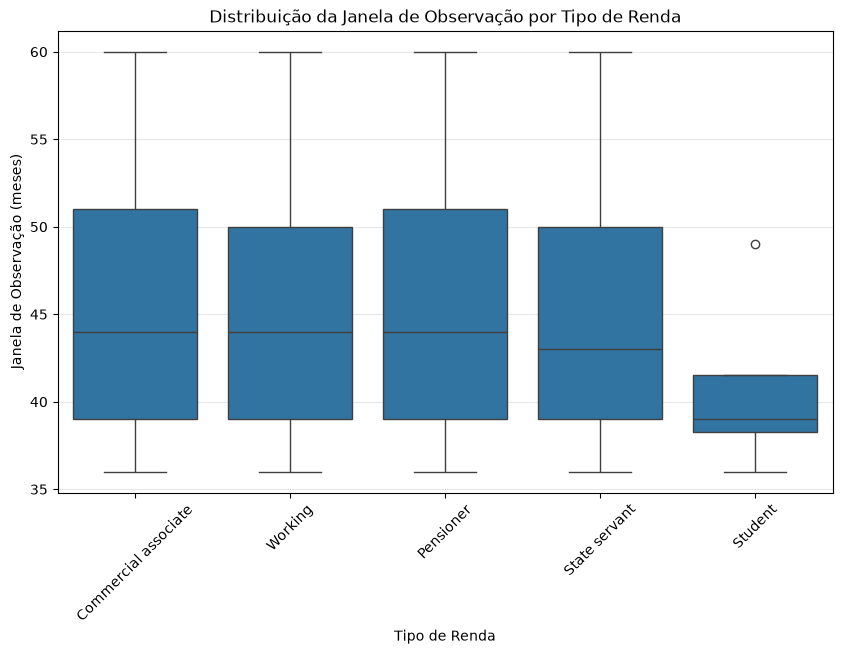

In [43]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_analysis,
    x='NAME_INCOME_TYPE',
    y='window'
)

plt.xlabel('Tipo de Renda')
plt.ylabel('Janela de Observação (meses)')
plt.title('Distribuição da Janela de Observação por Tipo de Renda')

plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

#### Result

The exposure hypothesis does not explain the higher bad rate in the Pensioner group, as the observation window is practically identical across groups. We will analyze this issue further to find a better explanation for this factor.

---

#### Resultado

A hipótese de exposição não explica a taxa mais alta de bad em Pensioner, já que a janela de observação é praticamente igual entre os grupos. Posteriormente analisaremos essa questão para encontrar uma melhor explicação para esse fator.

In [44]:
def plot_kde_good_bad(df, variable, xlabel, title):
    
    plt.figure(figsize=(12, 6))
    
    sns.kdeplot(
        data=df[df['TARGET'] == 0],
        x=variable,
        fill=True,
        common_norm=False,
        label='Good',
        linewidth=2
    )
    
    sns.kdeplot(
        data=df[df['TARGET'] == 1],
        x=variable,
        fill=True,
        common_norm=False,
        label='Bad',
        linewidth=2
    )
    
    plt.xlabel(xlabel)
    plt.ylabel('Densidade')
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

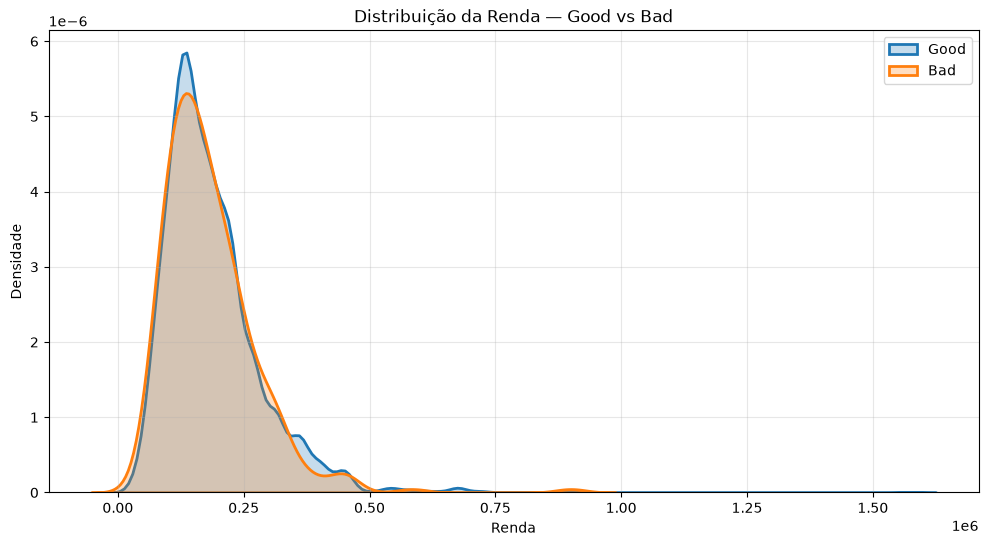

In [45]:
plot_kde_good_bad(
    df_analysis,
    'AMT_INCOME_TOTAL',
    'Renda',
    'Distribuição da Renda — Good vs Bad'
)

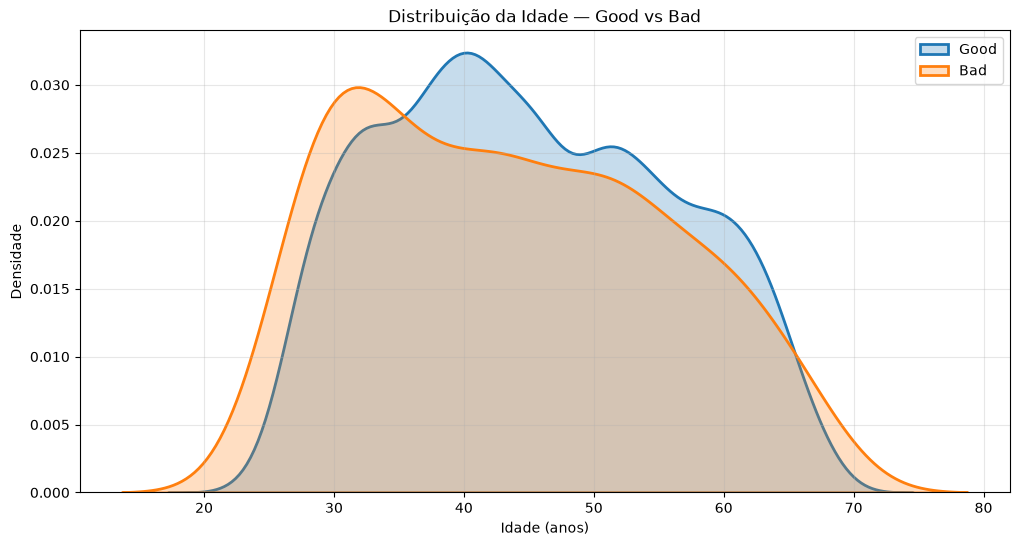

In [46]:
plot_kde_good_bad(
    df_analysis,
    'AGE_YEARS',
    'Idade (anos)',
    'Distribuição da Idade — Good vs Bad'
)

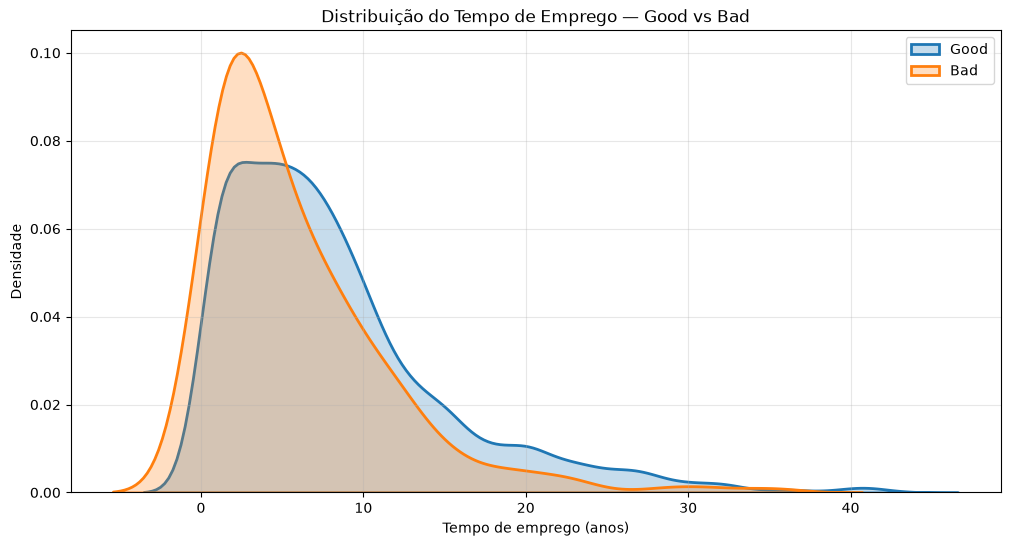

In [47]:
plot_kde_good_bad(
    df_analysis,
    'EMPLOYED_YEARS',
    'Tempo de emprego (anos)',
    'Distribuição do Tempo de Emprego — Good vs Bad'
)

In [48]:
numerical_variables = [
    'AMT_INCOME_TOTAL',
    'AGE_YEARS',
    'EMPLOYED_YEARS'
]

summary_numeric = (
    df_analysis.groupby('TARGET')[numerical_variables]
    .agg(['count', 'mean', 'median', 'std'])
)

summary_numeric

AMT_INCOME_TOTAL                                 AGE_YEARS        \
                  count       mean     median       std     count  mean   
TARGET                                                                    
0                  6357 187,223.60 162,000.00 98,336.83      6357 44.98   
1                   294 182,176.53 159,750.00 93,101.39       294 43.56   

                    EMPLOYED_YEARS                   
       median   std          count mean median  std  
TARGET                                               
0       44.06 10.90           5280 8.19   6.59 6.90  
1       42.65 11.76            238 5.86   4.41 5.58

#### Insights

- The average income of Bad customers is approximately equal to that of Good customers.

- The average age is lower for Bad customers, characterizing a younger customer profile.

- Bad customers have a lower average length of employment than Good customers, indicating that a lack of job stability may be a factor in default.

- Widowed customers have the highest default rate by marital status, at 7.66%.

- There is a visible difference in risk across education levels, but without an explicit pattern.

- Pensioner customers have a default rate of 5.28% (60 out of 1,137), higher than Commercial Associates at 4.47% (69 out of 1,543) and the 4.24% observed in Workers (145 out of 3,422). The absolute number of bad cases is higher in Workers and Commercial Associates, but proportionally, the risk is higher among Pensioners. In the Risk Index calculation, Pensioners are 19% above the overall average rate.

---

#### Insights

- A média salarial dos clientes Bad é aproximadamente igual aos dos clientes Good.

- A média de idade é menor para os clientes Bad, caracterizando um perfil mais jovem dos clientes.

- Os clientes Bad apresentam uma média de tempo empregado inferior aos dos clientes Good, demonstrando que a falta de estabilidade no trabalho seja um fator para inadimplência.

- Clientes viúvos(a) apresentam a maior taxa de inadimplência entre os estados civis com 7,66%. 

- Existe diferença visível de risco entre níveis de escolaridade, mas sem um padrão explícito.

- Clientes Pensionistas apresentam taxa de inadimplência de 5,28% (60 de 1.137), superior aos Associados Comerciais de 4,47% (69 de 1543) e aos 4,24% observados em Trabalhadores (145 de 3.422). O número absoluto de casos bad é maior em Trabalhadores e Associados Comerciais, mas proporcionalmente, o risco é maior entre Pensionistas. No cálculo de Índice de Risco, os Pensionistas apresentam 19% acima da média da taxa geral.


#### Column Preprocessing for Training

The cells below will focus on preprocessing the DataFrame columns before proceeding with training the Machine Learning model.

--- 

#### Tratamento das colunas para treinamento

As células abaixo serão focadas no tratamento das colunas do DataFrame para posteriormente seguir com o treinamento do modelo de Machine Learning.

In [49]:
df_analysis['EMPLOYED_SPECIAL'] = (
    df_analysis['DAYS_EMPLOYED'] == 365243
)

df_analysis['EMPLOYED_YEARS'] = (
    df_analysis['DAYS_EMPLOYED'].abs() / 365
).round(2)

df_analysis.loc[
    df_analysis['EMPLOYED_SPECIAL'],
    'EMPLOYED_YEARS'
] = np.nan

df_analysis['EMPLOYED_YEARS'] = (
    df_analysis['EMPLOYED_YEARS']
    .fillna(0)
)

# O tratamento acima é importante para que o modelo consiga diferenciar os clientes que possuem o valor especial (365243) dos demais.
# Atribuindo a eles um valor de 0 anos de emprego. Isso permite que o modelo capture a informação de que esses clientes têm um histórico de emprego atípico.
# O que pode ser relevante para a análise de risco de crédito.

In [50]:
df_analysis['OCCUPATION_TYPE'] = (
    df_analysis['OCCUPATION_TYPE']
    .fillna('Not_Informed')
)

# Realizando esse tratamento na coluna OCCUPATION_TYPE, com o One-Hot Encoding transforma as variáveis categóricas em variáveis binárias (0 ou 1).

In [51]:
# Variáveis binárias: conversão direta para 0/1

binary_mappings = {
    'CODE_GENDER': {'F': 0, 'M': 1},
    'FLAG_OWN_CAR': {'N': 0, 'Y': 1},
    'FLAG_OWN_REALTY': {'N': 0, 'Y': 1},
}

for col, mapping in binary_mappings.items():
    df_analysis[col] = df_analysis[col].map(mapping).astype('int8')

for col in binary_mappings:
    print(f'\n{col}:')
    print(df_analysis[col].value_counts(dropna=False))

print(
    '\nValores únicos de FLAG_MOBIL:',
    df_analysis['FLAG_MOBIL'].nunique(dropna=False)
)

print(
    df_analysis['FLAG_MOBIL'].value_counts(dropna=False)
)

if df_analysis['FLAG_MOBIL'].nunique(dropna=False) == 1:
    df_analysis.drop(columns='FLAG_MOBIL', inplace=True)
    print('\nFLAG_MOBIL removida: variável constante.')
else:
    print('\nFLAG_MOBIL mantida: possui mais de um valor.')

columns_to_drop = [
    'ID',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
    'window',
    'open_month',
    'Pensioner',
    'elective_group'
]

df_analysis.drop(
    columns=columns_to_drop,
    inplace=True,
    errors='ignore'
)


CODE_GENDER:
CODE_GENDER
0    4438
1    2213
Name: count, dtype: int64

FLAG_OWN_CAR:
FLAG_OWN_CAR
0    4024
1    2627
Name: count, dtype: int64

FLAG_OWN_REALTY:
FLAG_OWN_REALTY
1    4334
0    2317
Name: count, dtype: int64

Valores únicos de FLAG_MOBIL: 1
FLAG_MOBIL
1    6651
Name: count, dtype: int64

FLAG_MOBIL removida: variável constante.


Since a Random Forest/Boosting model will be used, I opted to remove the elective_group column so that the model can rediscover the pattern on its own.

---

Como será utilizado o modelo Random Forest/Boosting, optei por remover a coluna elective_group, para que o modelo possa redescobrir o padrão sozinho.

In [52]:
# Confirmando o tratamento das variáveis categóricas e a ausência de valores nulos no DataFrame df_analysis.

df_analysis.isnull().sum()

CODE_GENDER            0
FLAG_OWN_CAR           0
FLAG_OWN_REALTY        0
CNT_CHILDREN           0
AMT_INCOME_TOTAL       0
NAME_INCOME_TYPE       0
NAME_EDUCATION_TYPE    0
NAME_FAMILY_STATUS     0
NAME_HOUSING_TYPE      0
FLAG_WORK_PHONE        0
FLAG_PHONE             0
FLAG_EMAIL             0
OCCUPATION_TYPE        0
CNT_FAM_MEMBERS        0
TARGET                 0
AGE_YEARS              0
EMPLOYED_YEARS         0
EMPLOYED_SPECIAL       0
dtype: int64

#### Model Training and Testing

---

#### Treinamento e Teste do Modelo

In [53]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE',
    'OCCUPATION_TYPE'
]

numeric_features = [
    col
    for col in df_analysis.columns
    if col not in categorical_features + ['TARGET']
]

print('Variáveis categóricas:')
print(categorical_features)

print('\nVariáveis numéricas:')
print(numeric_features)

Variáveis categóricas:
['NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']

Variáveis numéricas:
['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'AGE_YEARS', 'EMPLOYED_YEARS', 'EMPLOYED_SPECIAL']


In [54]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(
                handle_unknown='ignore',
                drop=None,
                sparse_output=False
            ),
            categorical_features
        )
    ],
    remainder='passthrough'
)

In [55]:
from sklearn.model_selection import train_test_split

x = df_analysis.drop(columns='TARGET')
y = df_analysis['TARGET']

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Distribuição no treino:")
print(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nDistribuição no teste:")
print(
    y_test.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Distribuição no treino:
TARGET
0   95.58
1    4.42
Name: proportion, dtype: float64

Distribuição no teste:
TARGET
0   95.57
1    4.43
Name: proportion, dtype: float64


In [56]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    (
        'model',
        RandomForestClassifier(
            n_estimators=300,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        )
    )
])

In [57]:
from sklearn.ensemble import GradientBoostingClassifier

gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    (
        'model',
        GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        )
    )
])

In [58]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weight_gb = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

In [59]:
# Treinamento do modelo Random Forest
rf_pipeline.fit(
    x_train,
    y_train
)

# Treinamento do modelo Gradient Boosting com pesos de amostra
gb_pipeline.fit(
    x_train,
    y_train,
    model__sample_weight=sample_weight_gb
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int8](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['CODE_GENDER','FLAG_OWN_CAR','FLAG_OWN_REALTY',...,'AGE_YEARS', 'EMPLOYED_YEARS','EMPLOYED_SPECIAL']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainde

In [60]:
# Previsões do Random Forest
y_pred_rf = rf_pipeline.predict(x_test)
y_prob_rf = rf_pipeline.predict_proba(x_test)[:, 1]

# Previsões do Gradient Boosting
y_pred_gb = gb_pipeline.predict(x_test)
y_prob_gb = gb_pipeline.predict_proba(x_test)[:, 1]

In [61]:
from sklearn.metrics import confusion_matrix, classification_report

print("Random Forest")
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["Good", "Bad"],
        digits=4
    )
)

Random Forest

Matriz de Confusão:
[[1251   21]
 [  38   21]]

Classification Report:
              precision    recall  f1-score   support

        Good     0.9705    0.9835    0.9770      1272
         Bad     0.5000    0.3559    0.4158        59

    accuracy                         0.9557      1331
   macro avg     0.7353    0.6697    0.6964      1331
weighted avg     0.9497    0.9557    0.9521      1331



In [62]:
print("Gradient Boosting")
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred_gb))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_gb,
        target_names=["Good", "Bad"],
        digits=4
    )
)

Gradient Boosting

Matriz de Confusão:
[[1003  269]
 [  32   27]]

Classification Report:
              precision    recall  f1-score   support

        Good     0.9691    0.7885    0.8695      1272
         Bad     0.0912    0.4576    0.1521        59

    accuracy                         0.7739      1331
   macro avg     0.5301    0.6231    0.5108      1331
weighted avg     0.9302    0.7739    0.8377      1331



In [63]:
from sklearn.metrics import roc_auc_score, average_precision_score

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
pr_auc_rf = average_precision_score(y_test, y_prob_rf)

roc_auc_gb = roc_auc_score(y_test, y_prob_gb)
pr_auc_gb = average_precision_score(y_test, y_prob_gb)

print(f"Random Forest - ROC-AUC: {roc_auc_rf:.4f}")
print(f"Random Forest - PR-AUC:  {pr_auc_rf:.4f}")

print(f"\nGradient Boosting - ROC-AUC: {roc_auc_gb:.4f}")
print(f"Gradient Boosting - PR-AUC:  {pr_auc_gb:.4f}")

Random Forest - ROC-AUC: 0.7247
Random Forest - PR-AUC:  0.3146

Gradient Boosting - ROC-AUC: 0.6484
Gradient Boosting - PR-AUC:  0.1254


In [64]:
from sklearn.metrics import precision_score, recall_score, f1_score

resultados = pd.DataFrame({
    "Modelo": ["Random Forest", "Gradient Boosting"],
    "Precision_Bad": [
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_gb)
    ],
    "Recall_Bad": [
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gb)
    ],
    "F1_Bad": [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb)
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_gb)
    ],
    "PR_AUC": [
        average_precision_score(y_test, y_prob_rf),
        average_precision_score(y_test, y_prob_gb)
    ]
})

resultados.round(4)

,Modelo,Precision_Bad,Recall_Bad,F1_Bad,ROC_AUC,PR_AUC
0,Random Forest,0.50,0.36,0.42,0.72,0.31
1,Gradient Boosting,0.09,0.46,0.15,0.65,0.13


##### Model Refinement

Based on the presented results, the Random Forest model has consolidated itself as the best model for this problem. However, to be certain, I will proceed with refining both models to definitively select the best model for this project.

--- 

##### Refinamento dos Modelos

Se baseando nos resultados apresentados, o modelo de Random Forest se consolidou como melhor modelo para esse problema, mas para ter uma melhor certeza, seguirei para um refinamento de ambos os modelos para definir de fato o melhor modelo para esse projeto.

In [65]:
# Guardando o resultado para comparação futura

resultados_antes = resultados.copy()

In [66]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [68]:
param_distributions_rf = {
    'model__n_estimators': [200, 300, 500, 800],
    'model__max_depth': [None, 5, 8, 12],
    'model__min_samples_leaf': [1, 2, 5, 10]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions_rf,
    n_iter=20,
    scoring='average_precision',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    refit=True
)

In [69]:
rf_search.fit(
    x_train,
    y_train
)

print("Melhores parâmetros:")
print(rf_search.best_params_)

print("\nMelhor score médio de validação:")
print(rf_search.best_score_)

rf_best = rf_search.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Melhores parâmetros:
{'model__n_estimators': 300, 'model__min_samples_leaf': 2, 'model__max_depth': None}

Melhor score médio de validação:
0.25874645810749064


In [70]:
param_distributions_gb = {
    'model__learning_rate': [0.02, 0.05, 0.1],
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [2, 3, 4, 5]
}

gb_search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=param_distributions_gb,
    n_iter=20,
    scoring='average_precision',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    refit=True
)

In [71]:
gb_search.fit(
    x_train,
    y_train,
    model__sample_weight=sample_weight_gb
)

print("Melhores parâmetros:")
print(gb_search.best_params_)

print("\nMelhor score médio de validação:")
print(gb_search.best_score_)

gb_best = gb_search.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Melhores parâmetros:
{'model__n_estimators': 500, 'model__max_depth': 4, 'model__learning_rate': 0.1}

Melhor score médio de validação:
0.24285572495577928


In [72]:
# Random Forest refinado
y_pred_rf_tuned = rf_best.predict(x_test)
y_prob_rf_tuned = rf_best.predict_proba(x_test)[:, 1]

# Gradient Boosting refinado
y_pred_gb_tuned = gb_best.predict(x_test)
y_prob_gb_tuned = gb_best.predict_proba(x_test)[:, 1]

In [73]:
print("Random Forest - Refinado")

print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred_rf_tuned))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf_tuned,
        target_names=["Good", "Bad"],
        digits=4
    )
)

print(
    f"\nROC-AUC: "
    f"{roc_auc_score(y_test, y_prob_rf_tuned):.4f}"
)

print(
    f"PR-AUC: "
    f"{average_precision_score(y_test, y_prob_rf_tuned):.4f}"
)

Random Forest - Refinado

Matriz de Confusão:
[[1247   25]
 [  38   21]]

Classification Report:
              precision    recall  f1-score   support

        Good     0.9704    0.9803    0.9754      1272
         Bad     0.4565    0.3559    0.4000        59

    accuracy                         0.9527      1331
   macro avg     0.7135    0.6681    0.6877      1331
weighted avg     0.9476    0.9527    0.9499      1331


ROC-AUC: 0.7110
PR-AUC: 0.3282


In [74]:
print("Gradient Boosting - Refinado")

print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred_gb_tuned))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_gb_tuned,
        target_names=["Good", "Bad"],
        digits=4
    )
)

print(
    f"\nROC-AUC: "
    f"{roc_auc_score(y_test, y_prob_gb_tuned):.4f}"
)

print(
    f"PR-AUC: "
    f"{average_precision_score(y_test, y_prob_gb_tuned):.4f}"
)

Gradient Boosting - Refinado

Matriz de Confusão:
[[1226   46]
 [  36   23]]

Classification Report:
              precision    recall  f1-score   support

        Good     0.9715    0.9638    0.9676      1272
         Bad     0.3333    0.3898    0.3594        59

    accuracy                         0.9384      1331
   macro avg     0.6524    0.6768    0.6635      1331
weighted avg     0.9432    0.9384    0.9407      1331


ROC-AUC: 0.6926
PR-AUC: 0.3113


In [75]:
resultados_depois = pd.DataFrame({
    "Modelo": [
        "Random Forest - Antes",
        "Random Forest - Refinado",
        "Gradient Boosting - Antes",
        "Gradient Boosting - Refinado"
    ],
    
    "Precision_Bad": [
        resultados_antes.loc[
            resultados_antes["Modelo"] == "Random Forest",
            "Precision_Bad"
        ].iloc[0],

        precision_score(y_test, y_pred_rf_tuned),

        resultados_antes.loc[
            resultados_antes["Modelo"] == "Gradient Boosting",
            "Precision_Bad"
        ].iloc[0],

        precision_score(y_test, y_pred_gb_tuned)
    ],
    
    "Recall_Bad": [
        resultados_antes.loc[
            resultados_antes["Modelo"] == "Random Forest",
            "Recall_Bad"
        ].iloc[0],

        recall_score(y_test, y_pred_rf_tuned),

        resultados_antes.loc[
            resultados_antes["Modelo"] == "Gradient Boosting",
            "Recall_Bad"
        ].iloc[0],

        recall_score(y_test, y_pred_gb_tuned)
    ],
    
    "F1_Bad": [
        resultados_antes.loc[
            resultados_antes["Modelo"] == "Random Forest",
            "F1_Bad"
        ].iloc[0],

        f1_score(y_test, y_pred_rf_tuned),

        resultados_antes.loc[
            resultados_antes["Modelo"] == "Gradient Boosting",
            "F1_Bad"
        ].iloc[0],

        f1_score(y_test, y_pred_gb_tuned)
    ],
    
    "ROC_AUC": [
        resultados_antes.loc[
            resultados_antes["Modelo"] == "Random Forest",
            "ROC_AUC"
        ].iloc[0],

        roc_auc_score(y_test, y_prob_rf_tuned),

        resultados_antes.loc[
            resultados_antes["Modelo"] == "Gradient Boosting",
            "ROC_AUC"
        ].iloc[0],

        roc_auc_score(y_test, y_prob_gb_tuned)
    ],
    
    "PR_AUC": [
        resultados_antes.loc[
            resultados_antes["Modelo"] == "Random Forest",
            "PR_AUC"
        ].iloc[0],

        average_precision_score(y_test, y_prob_rf_tuned),

        resultados_antes.loc[
            resultados_antes["Modelo"] == "Gradient Boosting",
            "PR_AUC"
        ].iloc[0],

        average_precision_score(y_test, y_prob_gb_tuned)
    ]
})

resultados_depois.round(4)

,Modelo,Precision_Bad,Recall_Bad,F1_Bad,ROC_AUC,PR_AUC
0,Random Forest - Antes,0.50,0.36,0.42,0.72,0.31
1,Random Forest - Refinado,0.46,0.36,0.40,0.71,0.33
2,Gradient Boosting - Antes,0.09,0.46,0.15,0.65,0.13
3,Gradient Boosting - Refinado,0.33,0.39,0.36,0.69,0.31


## Project Conclusion

This project began with a challenge that, for me, was one of the most interesting parts of the analysis: the dataset did not have a ready-to-use TARGET variable. Before thinking about modeling, it was necessary to understand customer behavior over time and construct a definition of default that made sense for the problem.

Based on the vintage analysis, I chose to consider a minimum observation window of 36 months and defined a "bad" customer as one who presented a default exceeding 60 days. This choice allowed capturing approximately 61% of the default events observed over the lifetime of the dataset, but it also brought an important limitation: about 40% of the events that occurred after this period were excluded. On the other hand, this decision preserved approximately 21% of the customer base for modeling. Therefore, right from the beginning, there was a trade-off between having a longer observation window and maintaining a reasonable number of customers for training.

During the exploratory data analysis, one of the main challenges encountered was the severe class imbalance of the target variable: only about 4.4% of the customers were classified as "bad." Additionally, some interesting patterns emerged. Younger customers, those with shorter employment history, widowers, and pensioners showed default rates above the portfolio average. The case of pensioners particularly drew attention as it seemed counterintuitive. For this reason, this hypothesis was investigated, and the difference could not be explained simply by a higher exposure of these customers in the dataset, given that their observation windows were very similar to those of the other groups.

Another critical aspect was data preprocessing before training. Certain values could easily lead to incorrect conclusions, such as the code 365243 used as a sentinel value in DAYS_EMPLOYED. Instead of treating this value as actual employment duration, it was identified separately to avoid distorting the analysis; the same care was applied to categorical variables and missing values.

In the modeling phase, I chose to work with Random Forest and Gradient Boosting. The idea was not merely to train two models, but to observe how different algorithms would behave when faced with such a small positive class. To address the class imbalance, I used class_weight in Random Forest and sample_weight in Gradient Boosting. Subsequently, both models were refined using RandomizedSearchCV, with stratified cross-validation and optimization based on PR-AUC.

The results revealed some interesting differences. Prior to refinement, Random Forest achieved a Precision of 0.50, Recall of 0.36, and F1-score of 0.42 for the "bad" class, whereas Gradient Boosting yielded a Precision of 0.09, Recall of 0.46, and F1-score of 0.15. After hyperparameter tuning, Random Forest resulted in a Precision of 0.46, Recall of 0.36, and F1-score of 0.40, with PR-AUC increasing from 0.31 to 0.33. Meanwhile, Gradient Boosting experienced a more significant shift: its PR-AUC rose from 0.13 to 0.31, while its F1-score increased from 0.15 to 0.36.

These results indicate that tuning had different impacts on each model. In Gradient Boosting, in particular, adjusting the hyperparameters substantially altered the model's behavior. At the same time, the problem remains challenging: even after refinement, the recall for the "bad" class remained around 36% for Random Forest and 39% for Gradient Boosting. In other words, a relevant portion of customers who actually defaulted is still not identified by the model when using the default threshold of 0.5.

Therefore, I consider that the most important outcome of this project is not simply selecting an algorithm, but understanding the limitations and trade-offs involved in model construction. The target definition, observation window, class imbalance, and threshold selection can have as much impact as the algorithm itself.

As next steps, a natural evolution would be testing different classification thresholds while taking into account the business cost of each error type. In practice, a balance exists between detecting more high-risk default customers and avoiding misclassifying good customers as "bad." It would also be worthwhile to experiment with other sampling strategies for class imbalance, such as SMOTE, and to evaluate whether a longer observation window—even if it further reduces sample size—could produce a more reliable TARGET.

Ultimately, the project demonstrated that building a credit risk model goes far beyond fitting a classification algorithm; a major part of the work lies in understanding the data, properly defining the problem, and recognizing the limitations of the results before translating them into business decisions.

---

## Conclusão do Projeto

Este projeto começou com um desafio que, para mim, foi uma das partes mais interessantes da análise: a base não possuía um TARGET pronto. Antes de pensar em modelo, foi necessário entender o comportamento dos clientes ao longo do tempo e construir uma definição de inadimplência que fizesse sentido para o problema.

A partir da análise de vintage, optei por considerar uma janela mínima de observação de 36 meses e definir como "bad" o cliente que apresentou atraso superior a 60 dias. Essa escolha permitiu capturar aproximadamente 61% dos eventos de inadimplência observados ao longo da vida da base, mas também trouxe uma limitação importante: cerca de 40% dos eventos que aconteceram depois desse período ficaram de fora. Em contrapartida, essa escolha permitiu preservar aproximadamente 21% da base de clientes para a modelagem. Portanto, desde o início, houve um equilíbrio entre ter uma janela de observação mais longa e manter uma quantidade razoável de clientes para o treinamento.

Durante a análise exploratória, um dos principais desafios encontrados foi o forte desbalanceamento da variável alvo: apenas cerca de 4,4% dos clientes foram classificados como "bad". Além disso, surgiram alguns padrões interessantes. Clientes mais jovens, com menor tempo de emprego, viúvos e pensionistas apresentaram taxas de inadimplência acima da média da carteira. O caso dos pensionistas chamou especialmente a atenção, por parecer contraintuitivo. Por isso, essa hipótese foi investigada e a diferença não pôde ser explicada simplesmente por uma maior exposição desses clientes na base, já que suas janelas de observação eram muito semelhantes às dos demais grupos.

Outro ponto importante foi o tratamento das variáveis antes do treinamento. Alguns valores poderiam facilmente levar a conclusões erradas, como o código 365243 utilizado como valor sentinela em DAYS_EMPLOYED. Em vez de simplesmente tratar esse valor como um tempo real de emprego, ele foi identificado separadamente para evitar que distorcesse a análise, o mesmo cuidado foi aplicado às variáveis categóricas e aos valores ausentes.

Na etapa de modelagem, escolhi trabalhar com Random Forest e Gradient Boosting. A ideia não era apenas treinar dois modelos, mas observar como diferentes algoritmos se comportariam diante de uma classe positiva tão pequena. Para lidar com o desbalanceamento, utilizei class_weight no Random Forest e sample_weight no Gradient Boosting. Depois, os dois modelos foram refinados utilizando RandomizedSearchCV, com validação estratificada e otimização baseada em PR-AUC.

Os resultados mostraram algumas diferenças interessantes. Antes do refinamento, o Random Forest apresentou Precision de 0,50, Recall de 0,36 e F1-score de 0,42 para a classe "bad", enquanto o Gradient Boosting apresentou Precision de 0,09, Recall de 0,46 e F1-score de 0,15. Após o tuning, o Random Forest ficou com Precision de 0,46, Recall de 0,36 e F1-score de 0,40, com PR-AUC passando de 0,31 para 0,33. Já o Gradient Boosting teve uma mudança mais significativa: a PR-AUC passou de 0,13 para 0,31, enquanto o F1-score subiu de 0,15 para 0,36.

Esses resultados mostram que o tuning teve impactos diferentes nos dois modelos. No Gradient Boosting, principalmente, o ajuste dos hiperparâmetros mudou bastante o comportamento do modelo. Ao mesmo tempo, o problema continua sendo difícil: mesmo após o refinamento, o recall da classe "bad" permaneceu em torno de 36% no Random Forest e 39% no Gradient Boosting. Ou seja, uma parcela relevante dos clientes que realmente apresentaram inadimplência ainda não é identificada pelo modelo utilizando o threshold padrão de 0,5.

Por isso, considero que o resultado mais importante deste projeto não é apenas escolher um algoritmo, mas entender as limitações e os trade-offs envolvidos na construção do modelo. A definição do target, a janela de observação, o desbalanceamento da base e a escolha do threshold podem ter tanto impacto quanto o próprio algoritmo utilizado.

Como próximos passos, uma evolução natural seria testar diferentes thresholds de classificação levando em consideração o custo de negócio de cada tipo de erro. Na prática, existe um equilíbrio entre identificar mais clientes com risco de inadimplência e evitar classificar bons clientes como "bad". Também seria interessante testar outras estratégias de tratamento do desbalanceamento, como SMOTE, e avaliar se uma janela de observação mais longa, mesmo reduzindo ainda mais o tamanho da amostra, poderia produzir um TARGET mais confiável.

No fim, o projeto mostrou que construir um modelo de risco de crédito vai muito além de aplicar um algoritmo de classificação, grande parte do trabalho está em entender os dados, definir corretamente o problema e reconhecer as limitações do resultado antes de transformá-lo em uma decisão de negócio.